# How this notebook is laid out - Function Approximation Showdown

1) First load required packages
2) Implement the warehouse environment
3) Implement discretized Q-Learning and plot
4) Implement tile-coded linear Q-Learning and plot
5) Implement DQN and plot
6) Compare all three models and plot on single chart
7) Ablation study for DQN
8) Write three-page report (see report.pdf or report.tex in the \report folder) but answers are also in this notebook


## Introduction



In [13]:
# Verify required packages are available
import sys
import subprocess
print(f"Python version: {sys.version}")

try:
    import numpy as np
    print(f"✓ numpy {np.__version__} is available")
except ImportError as e:
    print(f"✗ numpy not available: {e}")

try:
    import pandas as pd
    print(f"✓ pandas {pd.__version__} is available")
except ImportError as e:
    print(f"✗ pandas not available: {e}")

try:
    import matplotlib.pyplot as plt
    print("✓ matplotlib is available")
except ImportError as e:
    print(f"✗ matplotlib not available: {e}")

try:
    import sklearn
    print(f"✓ scikit-learn {sklearn.__version__} is available")
except ImportError as e:
    print(f"✗ scikit-learn not available: {e}")
    print("Installing scikit-learn...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--break-system-packages", "scikit-learn"])

try:
    import torch
except ImportError:
    print("PyTorch not found. Installing torch...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--break-system-packages", "torch"])
    import torch

import torch.nn as nn
import torch.optim as optim
from collections import deque
import random

print(f"✓ PyTorch {torch.__version__} is available")
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✓ PyTorch loaded on: {device}")

print("All required packages are ready!")

Python version: 3.12.13 (main, Mar  3 2026, 12:39:30) [Clang 17.0.0 (clang-1700.6.3.2)]
✓ numpy 2.4.1 is available
✓ pandas 3.0.1 is available
✓ matplotlib is available
✓ scikit-learn 1.8.0 is available
✓ PyTorch 2.11.0 is available
✓ PyTorch loaded on: cpu
All required packages are ready!


## Task 1: Implement the CONTINUOUS Warehouse Environment

A continuous-state warehouse floor for function approximation experiments (Section 7.4.3: Warehouse Upgrade: Continuous Floor). The robot has state $(x, y, \theta, v) \in [0, 4]^2 \times [0, 2\pi) \times [0, 1]$ with 4 discrete actions (N/S/E/W). The hazard is at the center of the floor, directly in the path from start to goal.

In [14]:
class ContinuousWarehouse:
    """Continuous-state warehouse with center hazard.
    State: (x, y, theta, v)
      - (x, y): position on the floor, [0, 4]^2
      - theta: heading angle, [0, 2*pi)
      - v: velocity, [0, 1]
    Actions: 0=North, 1=South, 2=East, 3=West
    """
    ACTION_DELTAS = np.array([[0, 1], [0, -1], [1, 0], [-1, 0]],
                             dtype=float)  # N, S, E, W
    N_ACTIONS = 4
    ACTION_NAMES = ['North', 'South', 'East', 'West']
    def __init__(self, goal_center=(3.5, 3.5), hazard_center=(2.0, 2.0),
                 goal_radius=0.5, hazard_radius=0.5,
                 step_size=0.5, noise_std=0.1):
        self.goal = np.array(goal_center)
        self.hazard = np.array(hazard_center)
        self.goal_radius = goal_radius
        self.hazard_radius = hazard_radius
        self.step_size = step_size
        self.noise_std = noise_std
    def reset(self):
        """Reset to a random start near the bottom-left."""
        x = np.random.uniform(0.2, 0.8)
        y = np.random.uniform(0.2, 0.8)
        theta = np.random.uniform(0, 2 * np.pi)
        v = 0.0
        self.state = np.array([x, y, theta, v])
        return self.state.copy()
    def step(self, action):
        """Execute action, return (next_state, reward, done)."""
        x, y, theta, v = self.state
        # Movement: step in the cardinal direction + noise
        delta = self.ACTION_DELTAS[action] * self.step_size
        noise = np.random.randn(2) * self.noise_std
        x += delta[0] + noise[0]
        y += delta[1] + noise[1]
        # Update heading toward movement direction
        if np.linalg.norm(delta) > 0.01:
            theta = np.arctan2(delta[1], delta[0])
        v = np.linalg.norm(delta)
        # Wrap theta to [0, 2*pi), clip position and velocity
        theta = theta % (2 * np.pi)
        x = np.clip(x, 0.0, 4.0)
        y = np.clip(y, 0.0, 4.0)
        v = np.clip(v, 0.0, 1.0)
        self.state = np.array([x, y, theta, v])
        pos = np.array([x, y])
        if np.linalg.norm(pos - self.goal) < self.goal_radius:
            return self.state.copy(), 1.0, True
        elif np.linalg.norm(pos - self.hazard) < self.hazard_radius:
            return self.state.copy(), -1.0, True
        else:
            return self.state.copy(), -0.01, False
    def normalize_state(self, state):
        """Normalize state to [0, 1] for neural network input."""
        s = state.copy()
        s[0] /= 4.0
        s[1] /= 4.0
        s[2] /= (2 * np.pi)
        # v is already in [0, 1]
        return s

## Task 2: Implement Discretized Q-Learning

**Implement discretized Q-learning.** Discretize the $(x, y)$ position into a $10 \times 10$ grid (ignoring $\theta$ and $v$ for simplicity). Train for 2000 episodes. Plot the learning curve.

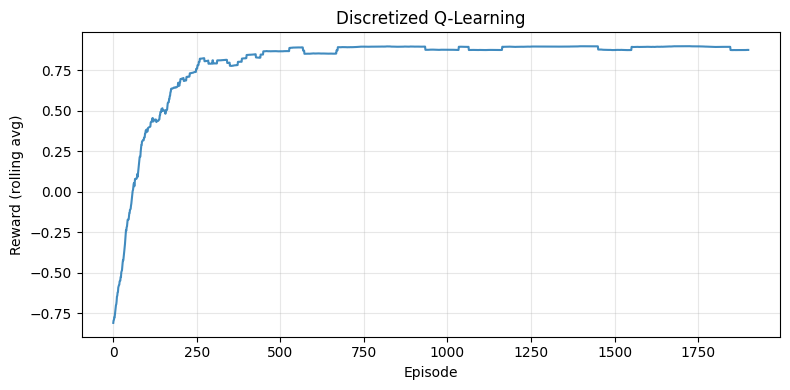

Discretized Q-learning parameters: 400


In [15]:
class DiscretizedQLearningAgent:
    """Tabular Q-learning on a 10x10 discretization of (x, y)."""
    def __init__(self, grid_size=10, n_actions=4, alpha=0.1, gamma=0.99):
        self.grid_size = grid_size
        self.n_actions = n_actions
        self.alpha = alpha
        self.gamma = gamma
        self.q_table = np.zeros((grid_size, grid_size, n_actions), dtype=np.float32)

    def discretize(self, state):
        x, y = state[0], state[1]
        x_bin = min(int(x / 4.0 * self.grid_size), self.grid_size - 1)
        y_bin = min(int(y / 4.0 * self.grid_size), self.grid_size - 1)
        return x_bin, y_bin

    def q_values(self, state):
        x_bin, y_bin = self.discretize(state)
        return self.q_table[x_bin, y_bin]

    def select_action(self, state, epsilon):
        if np.random.random() < epsilon:
            return np.random.randint(self.n_actions)
        return int(np.argmax(self.q_values(state)))

    def update(self, state, action, reward, next_state, done):
        x_bin, y_bin = self.discretize(state)
        current_q = self.q_table[x_bin, y_bin, action]
        if done:
            target = reward
        else:
            target = reward + self.gamma * np.max(self.q_values(next_state))
        self.q_table[x_bin, y_bin, action] += self.alpha * (target - current_q)


def train_discretized_q_learning(
    n_episodes=2000,
    epsilon_start=1.0,
    epsilon_decay=0.995,
    epsilon_min=0.01,
    seed=42,
):
    np.random.seed(seed)
    env = ContinuousWarehouse()
    agent = DiscretizedQLearningAgent()
    epsilon = epsilon_start
    rewards = []

    for _ in range(n_episodes):
        state = env.reset()
        done = False
        total_reward = 0.0
        steps = 0

        while not done and steps < 200:
            action = agent.select_action(state, epsilon)
            next_state, reward, done = env.step(action)
            agent.update(state, action, reward, next_state, done)
            state = next_state
            total_reward += reward
            steps += 1

        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        rewards.append(total_reward)

    return agent, rewards


def rolling_avg(data, window=100):
    data = np.asarray(data, dtype=float)
    if len(data) < window:
        return data
    return np.convolve(data, np.ones(window) / window, mode="valid")


agent_discretized, rewards_discretized = train_discretized_q_learning()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(rolling_avg(rewards_discretized), alpha=0.85)
ax.set_xlabel("Episode")
ax.set_ylabel("Reward (rolling avg)")
ax.set_title("Discretized Q-Learning")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Discretized Q-learning parameters: {agent_discretized.q_table.size}")

## Task 3: Implement tile-coded linear Q-Learning

**Implement tile-coded linear Q-learning.** Use 8 offset tilings of the $(x, y)$ space, each with a $4 \times 4$ grid of tiles. Each offset tiling needs one extra tile per dimension so that boundary tiles have their natural width (figure 7.1). Use the semi-gradient update from equation (7.18). Train for 2000 episodes. Plot the learning curve.

In [5]:
class TileCodedAgent:
    """Linear Q-learning with tile coding over (x, y)."""
    def __init__(self, n_tilings=8, tiles_per_dim=4, n_actions=4,
                 alpha=0.05, gamma=0.99):
        self.n_tilings = n_tilings
        self.tiles_per_dim = tiles_per_dim
        self.n_actions = n_actions
        self.alpha = alpha / n_tilings
        self.gamma = gamma
        # Extra tile per dim for offset tilings (boundary handling)
        self.ext = tiles_per_dim + 1
        self.tiles_per_tiling = self.ext ** 2
        self.n_features = n_tilings * self.tiles_per_tiling
        self.W = np.zeros((n_actions, self.n_features))
        self.tile_width = 4.0 / tiles_per_dim
        self.offsets = np.array([
            [k * self.tile_width / n_tilings,
             k * self.tile_width / n_tilings]
            for k in range(n_tilings)
        ])
    def get_features(self, state):
        """Binary feature vector from tile coding of (x, y)."""
        phi = np.zeros(self.n_features)
        x, y = state[0], state[1]
        for k in range(self.n_tilings):
            sx = x + self.offsets[k, 0]
            sy = y + self.offsets[k, 1]
            bx = int(sx / self.tile_width)
            by = int(sy / self.tile_width)
            bx = max(0, min(bx, self.ext - 1))
            by = max(0, min(by, self.ext - 1))
            idx = k * self.tiles_per_tiling + bx * self.ext + by
            phi[idx] = 1.0
        return phi
    def q_values(self, state):
        phi = self.get_features(state)
        return self.W @ phi
    def select_action(self, state, epsilon):
        if np.random.random() < epsilon:
            return np.random.randint(self.n_actions)
        return int(np.argmax(self.q_values(state)))
    def update(self, state, action, reward, next_state, done):
        phi = self.get_features(state)
        q_sa = self.W[action] @ phi
        if done:
            target = reward
        else:
            target = reward + self.gamma * np.max(
                self.q_values(next_state))
        self.W[action] += self.alpha * (target - q_sa) * phi

In [6]:
#Train agent
def train(n_episodes=2000, epsilon_start=1.0, epsilon_decay=0.995,
          epsilon_min=0.01, seed=42):
    np.random.seed(seed)
    env = ContinuousWarehouse()
    agent = TileCodedAgent()
    epsilon = epsilon_start
    rewards = []
    for _ in range(n_episodes):
        state = env.reset()
        done = False
        total_reward = 0
        steps = 0
        while not done and steps < 200:
            action = agent.select_action(state, epsilon)
            next_state, reward, done = env.step(action)
            agent.update(state, action, reward, next_state, done)
            state = next_state
            total_reward += reward
            steps += 1
        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        rewards.append(total_reward)
    return agent, rewards
agent, rewards = train()

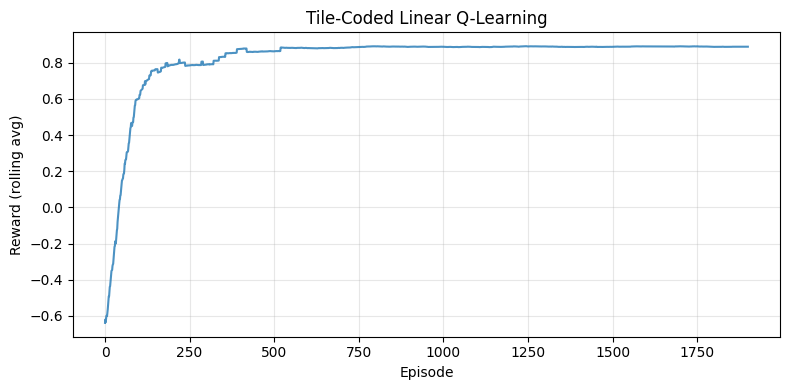

Tile-coded parameters: 800
  8 tilings x 25 tiles/tiling x 4 actions


In [8]:
#Plot the learning curve and show parameter counts
def rolling_avg(data, window=100):
    return np.convolve(data, np.ones(window)/window, mode='valid')
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(rolling_avg(rewards), alpha=0.8)
ax.set_xlabel('Episode')
ax.set_ylabel('Reward (rolling avg)')
ax.set_title('Tile-Coded Linear Q-Learning')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('tile_coded_curve.svg', bbox_inches='tight')
plt.show()

#Parameter Count
print(f"Tile-coded parameters: {agent.W.size}")
print(f"  {agent.n_tilings} tilings x "
      f"{agent.tiles_per_tiling} tiles/tiling x "
      f"{agent.n_actions} actions")

## Task 4: Implement DQN

**Implement DQN.** Build a neural network in PyTorch with 2 hidden layers (64 units each, ReLU) that takes the full state $(x, y, \theta, v)$ as input and outputs Q-values for all 4 actions. Implement experience replay (buffer size 10,000, batch size 64) and a target network (updated every 100 steps). Normalize state features to $[0,1]$ before passing to the network (comment 7.15). Train for 2000 episodes. Plot the learning curve.

Training DQN with replay + target network...


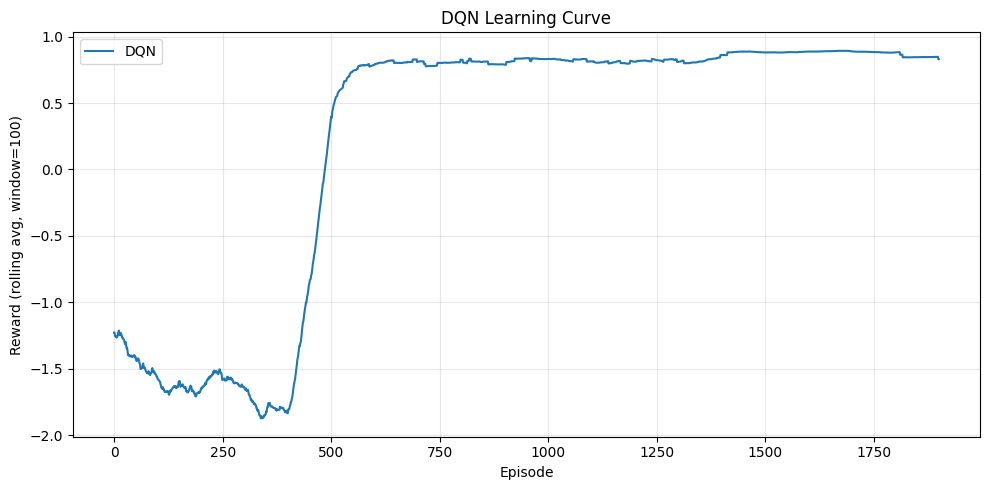

In [16]:
# DQN implementation for the continuous warehouse

class QNetwork(nn.Module):
    """Two-hidden-layer Q-network with 64-unit ReLU layers."""
    def __init__(self, state_dim=4, n_actions=4, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, n_actions),
        )

    def forward(self, x):
        return self.net(x)


class ReplayBuffer:
    def __init__(self, capacity=10_000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            np.array(states, dtype=np.float32),
            np.array(actions, dtype=np.int64),
            np.array(rewards, dtype=np.float32),
            np.array(next_states, dtype=np.float32),
            np.array(dones, dtype=np.float32),
        )

    def __len__(self):
        return len(self.buffer)


class DQNAgent:
    """DQN with replay buffer and target network."""
    def __init__(
        self,
        state_dim=4,
        n_actions=4,
        hidden=64,
        lr=1e-3,
        gamma=0.99,
        buffer_size=10_000,
        batch_size=64,
        target_update=100,
    ):
        self.n_actions = n_actions
        self.gamma = gamma
        self.batch_size = batch_size
        self.target_update = target_update
        self.step_count = 0

        self.q_net = QNetwork(state_dim, n_actions, hidden)
        self.target_net = QNetwork(state_dim, n_actions, hidden)
        self.target_net.load_state_dict(self.q_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.q_net.parameters(), lr=lr)
        self.buffer = ReplayBuffer(buffer_size)

    @staticmethod
    def normalize_state(state):
        """Normalize state features to [0, 1]."""
        s = state.copy().astype(np.float32)
        s[0] /= 4.0
        s[1] /= 4.0
        s[2] /= (2 * np.pi)
        # velocity s[3] is already in [0,1]
        return s

    def select_action(self, state, epsilon):
        if np.random.random() < epsilon:
            return np.random.randint(self.n_actions)
        with torch.no_grad():
            state_t = torch.FloatTensor(state).unsqueeze(0)
            return int(self.q_net(state_t).argmax(dim=1).item())

    def update(self):
        if len(self.buffer) < self.batch_size:
            return

        states, actions, rewards, next_states, dones = self.buffer.sample(self.batch_size)
        states_t = torch.FloatTensor(states)
        actions_t = torch.LongTensor(actions)
        rewards_t = torch.FloatTensor(rewards)
        next_states_t = torch.FloatTensor(next_states)
        dones_t = torch.FloatTensor(dones)

        q_values = self.q_net(states_t).gather(1, actions_t.unsqueeze(1)).squeeze(1)

        with torch.no_grad():
            next_q = self.target_net(next_states_t).max(dim=1)[0]
            targets = rewards_t + self.gamma * next_q * (1.0 - dones_t)

        loss = nn.MSELoss()(q_values, targets)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        self.step_count += 1
        if self.step_count % self.target_update == 0:
            self.target_net.load_state_dict(self.q_net.state_dict())


def train_dqn(
    n_episodes=2000,
    epsilon_start=1.0,
    epsilon_decay=0.995,
    epsilon_min=0.01,
    seed=42,
):
    np.random.seed(seed)
    torch.manual_seed(seed)

    env = ContinuousWarehouse()
    agent = DQNAgent()
    epsilon = epsilon_start
    rewards = []

    for _ in range(n_episodes):
        state = env.reset()
        done = False
        total_reward = 0.0
        steps = 0

        while not done and steps < 200:
            s_norm = DQNAgent.normalize_state(state)
            action = agent.select_action(s_norm, epsilon)
            next_state, reward, done = env.step(action)
            ns_norm = DQNAgent.normalize_state(next_state)
            agent.buffer.push(s_norm, action, reward, ns_norm, done)
            agent.update()

            state = next_state
            total_reward += reward
            steps += 1

        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        rewards.append(total_reward)

    return agent, rewards


def rolling_avg(data, window=100):
    data = np.asarray(data, dtype=float)
    if len(data) < window:
        return data
    return np.convolve(data, np.ones(window) / window, mode="valid")


print("Training DQN with replay + target network...")
agent_full, rewards_full = train_dqn(n_episodes=2000)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(rolling_avg(rewards_full, window=100), label="DQN")
ax.set_xlabel("Episode")
ax.set_ylabel("Reward (rolling avg, window=100)")
ax.set_title("DQN Learning Curve")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## Task 5: Compare All Three Approaches

**Compare all three approaches.** On the same axes, plot learning curves (rolling average reward, window 100) for all three agents. Report:

- Episodes to reach 80% of optimal performance
- Final average reward over the last 200 episodes
- Number of parameters for each approach

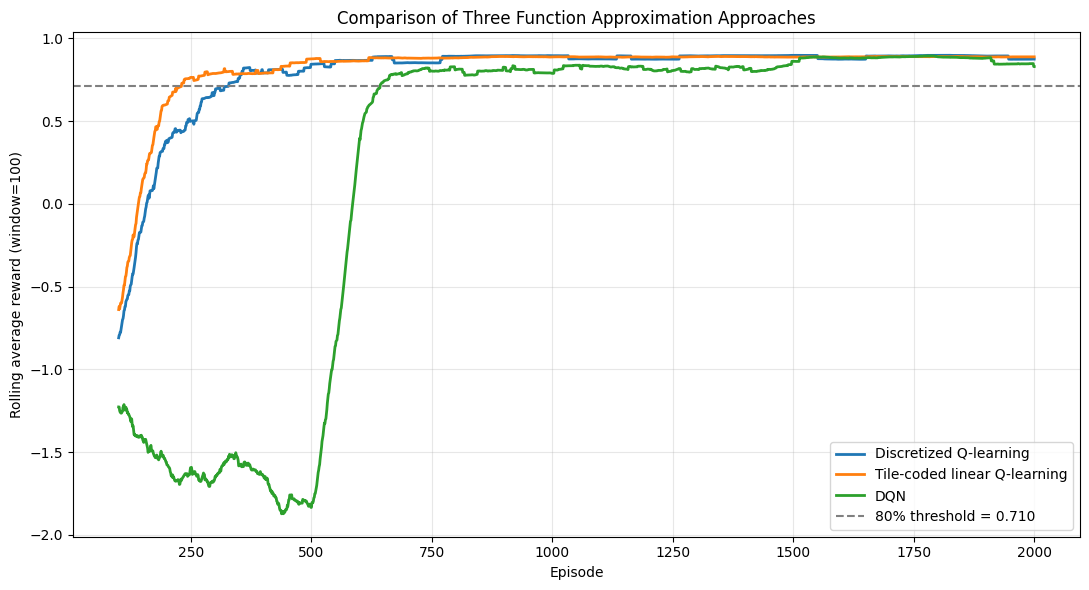

Comparison Report
80% of optimal performance threshold: 0.7103

Discretized Q-learning
  Episodes to reach 80% of optimal performance: 328
  Final average reward over last 200 episodes: 0.8839
  Number of parameters: 400

Tile-coded linear Q-learning
  Episodes to reach 80% of optimal performance: 231
  Final average reward over last 200 episodes: 0.8879
  Number of parameters: 800

DQN
  Episodes to reach 80% of optimal performance: 643
  Final average reward over last 200 episodes: 0.8554
  Number of parameters: 4740



In [17]:
import numpy as np
import matplotlib.pyplot as plt


def rolling_avg(data, window=100):
    data = np.asarray(data, dtype=float)
    if len(data) < window:
        return data
    return np.convolve(data, np.ones(window) / window, mode="valid")


def episodes_to_threshold(rewards, threshold, window=100):
    roll = rolling_avg(rewards, window=window)
    if len(roll) == 0:
        return None
    idx = np.where(roll >= threshold)[0]
    if len(idx) == 0:
        return None
    return int(idx[0] + window)


def parameter_count(agent):
    if hasattr(agent, "q_table"):
        return int(agent.q_table.size)
    if hasattr(agent, "W"):
        return int(agent.W.size)
    if hasattr(agent, "q_net"):
        return int(sum(p.numel() for p in agent.q_net.parameters()))
    return None


# Ensure tile-coded results exist (Task 3 cells might not have been run)
if "rewards_tile" not in globals() or "agent_tile" not in globals():
    if "train" in globals():
        agent_tile, rewards_tile = train()
    else:
        class TileCodedAgent:
            """Linear Q-learning with tile coding over (x, y)."""
            def __init__(self, n_tilings=8, tiles_per_dim=4, n_actions=4,
                         alpha=0.05, gamma=0.99):
                self.n_tilings = n_tilings
                self.tiles_per_dim = tiles_per_dim
                self.n_actions = n_actions
                self.alpha = alpha / n_tilings
                self.gamma = gamma
                self.ext = tiles_per_dim + 1
                self.tiles_per_tiling = self.ext ** 2
                self.n_features = n_tilings * self.tiles_per_tiling
                self.W = np.zeros((n_actions, self.n_features))
                self.tile_width = 4.0 / tiles_per_dim
                self.offsets = np.array([
                    [k * self.tile_width / n_tilings,
                     k * self.tile_width / n_tilings]
                    for k in range(n_tilings)
                ])

            def get_features(self, state):
                phi = np.zeros(self.n_features)
                x, y = state[0], state[1]
                for k in range(self.n_tilings):
                    sx = x + self.offsets[k, 0]
                    sy = y + self.offsets[k, 1]
                    bx = int(sx / self.tile_width)
                    by = int(sy / self.tile_width)
                    bx = max(0, min(bx, self.ext - 1))
                    by = max(0, min(by, self.ext - 1))
                    idx = k * self.tiles_per_tiling + bx * self.ext + by
                    phi[idx] = 1.0
                return phi

            def q_values(self, state):
                return self.W @ self.get_features(state)

            def select_action(self, state, epsilon):
                if np.random.random() < epsilon:
                    return np.random.randint(self.n_actions)
                return int(np.argmax(self.q_values(state)))

            def update(self, state, action, reward, next_state, done):
                phi = self.get_features(state)
                q_sa = self.W[action] @ phi
                target = reward if done else reward + self.gamma * np.max(self.q_values(next_state))
                self.W[action] += self.alpha * (target - q_sa) * phi

        def train_tile_coded(n_episodes=2000, epsilon_start=1.0, epsilon_decay=0.995,
                             epsilon_min=0.01, seed=42):
            np.random.seed(seed)
            env = ContinuousWarehouse()
            agent = TileCodedAgent()
            epsilon = epsilon_start
            rewards = []
            for _ in range(n_episodes):
                state = env.reset()
                done = False
                total_reward = 0.0
                steps = 0
                while not done and steps < 200:
                    action = agent.select_action(state, epsilon)
                    next_state, reward, done = env.step(action)
                    agent.update(state, action, reward, next_state, done)
                    state = next_state
                    total_reward += reward
                    steps += 1
                epsilon = max(epsilon_min, epsilon * epsilon_decay)
                rewards.append(total_reward)
            return agent, rewards

        agent_tile, rewards_tile = train_tile_coded()

# Build comparison set
comparison = {
    "Discretized Q-learning": (agent_discretized, rewards_discretized),
    "Tile-coded linear Q-learning": (agent_tile, rewards_tile),
    "DQN": (agent_full, rewards_full),
}

final_avg_200 = {name: float(np.mean(rew[-200:])) for name, (_, rew) in comparison.items()}
optimal_perf = max(final_avg_200.values())
threshold = 0.8 * optimal_perf

# Plot all three rolling-average learning curves on the same axes
plt.figure(figsize=(11, 6))
for name, (_, rewards) in comparison.items():
    r = rolling_avg(rewards, window=100)
    x = np.arange(100, 100 + len(r)) if len(r) >= 1 else np.arange(len(r))
    plt.plot(x, r, linewidth=2, label=name)

plt.axhline(threshold, color="gray", linestyle="--", linewidth=1.5,
            label=f"80% threshold = {threshold:.3f}")
plt.xlabel("Episode")
plt.ylabel("Rolling average reward (window=100)")
plt.title("Comparison of Three Function Approximation Approaches")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Report requested metrics
print("Comparison Report")
print(f"80% of optimal performance threshold: {threshold:.4f}")
print()
for name, (agent_obj, rewards) in comparison.items():
    ep80 = episodes_to_threshold(rewards, threshold, window=100)
    final_avg = final_avg_200[name]
    n_params = parameter_count(agent_obj)
    ep80_text = str(ep80) if ep80 is not None else "Not reached"
    params_text = str(n_params) if n_params is not None else "Unknown"

    print(name)
    print(f"  Episodes to reach 80% of optimal performance: {ep80_text}")
    print(f"  Final average reward over last 200 episodes: {final_avg:.4f}")
    print(f"  Number of parameters: {params_text}")
    print()

## Ablation Study for DQN

Train three variants:

- Full DQN (experience replay + target network)
- DQN without experience replay (train on most recent transition only)
- DQN without target network (use the online network for targets)
- Plot all three learning curves. Which component contributes more to stability?

Training ablation variants...


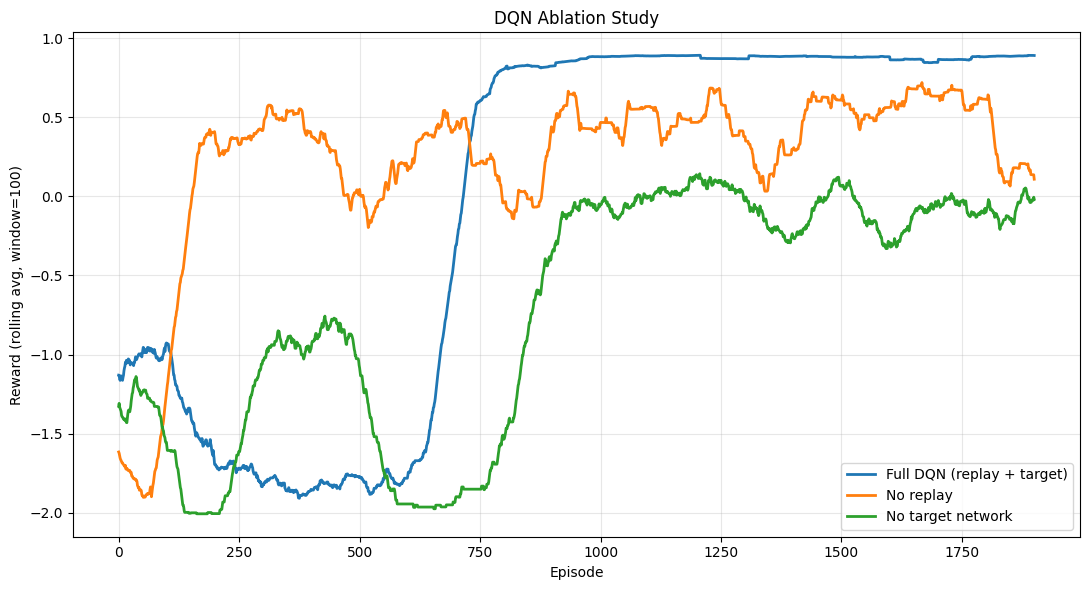

Final avg reward (last 200 episodes):
  Full DQN: 0.8862
  No replay: 0.3605
  No target: -0.0594

Stability proxy (std of tail rolling reward, lower is better):
  Full DQN: 0.0117
  No replay: 0.1738
  No target: 0.1028

Verdict: Experience replay appears to contribute more to stability.


In [18]:
# Ablation study for DQN: replay / target-network components

class AblationDQNAgent:
    def __init__(
        self,
        state_dim=4,
        n_actions=4,
        hidden=64,
        lr=1e-3,
        gamma=0.99,
        buffer_size=10_000,
        batch_size=64,
        target_update=100,
        use_replay=True,
        use_target_net=True,
    ):
        self.n_actions = n_actions
        self.gamma = gamma
        self.batch_size = batch_size
        self.target_update = target_update
        self.step_count = 0
        self.use_replay = use_replay
        self.use_target_net = use_target_net

        self.q_net = QNetwork(state_dim, n_actions, hidden)
        self.target_net = QNetwork(state_dim, n_actions, hidden)
        self.target_net.load_state_dict(self.q_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.q_net.parameters(), lr=lr)
        self.buffer = ReplayBuffer(buffer_size)

    @staticmethod
    def normalize_state(state):
        s = state.copy().astype(np.float32)
        s[0] /= 4.0
        s[1] /= 4.0
        s[2] /= (2 * np.pi)
        return s

    def select_action(self, state_norm, epsilon):
        if np.random.random() < epsilon:
            return np.random.randint(self.n_actions)
        with torch.no_grad():
            state_t = torch.FloatTensor(state_norm).unsqueeze(0)
            return int(self.q_net(state_t).argmax(dim=1).item())

    def update_from_transition(self, s_norm, action, reward, ns_norm, done):
        self.buffer.push(s_norm, action, reward, ns_norm, done)

        if self.use_replay:
            if len(self.buffer) < self.batch_size:
                return
            states, actions, rewards, next_states, dones = self.buffer.sample(self.batch_size)
        else:
            # Ablation: train from the most recent transition only
            states = np.array([s_norm], dtype=np.float32)
            actions = np.array([action], dtype=np.int64)
            rewards = np.array([reward], dtype=np.float32)
            next_states = np.array([ns_norm], dtype=np.float32)
            dones = np.array([done], dtype=np.float32)

        states_t = torch.FloatTensor(states)
        actions_t = torch.LongTensor(actions)
        rewards_t = torch.FloatTensor(rewards)
        next_states_t = torch.FloatTensor(next_states)
        dones_t = torch.FloatTensor(dones)

        q_values = self.q_net(states_t).gather(1, actions_t.unsqueeze(1)).squeeze(1)

        with torch.no_grad():
            if self.use_target_net:
                next_q = self.target_net(next_states_t).max(dim=1)[0]
            else:
                # Ablation: online network for targets
                next_q = self.q_net(next_states_t).max(dim=1)[0]
            targets = rewards_t + self.gamma * next_q * (1.0 - dones_t)

        loss = nn.MSELoss()(q_values, targets)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        self.step_count += 1
        if self.use_target_net and self.step_count % self.target_update == 0:
            self.target_net.load_state_dict(self.q_net.state_dict())


def train_dqn_ablation(
    use_replay=True,
    use_target_net=True,
    n_episodes=2000,
    epsilon_start=1.0,
    epsilon_decay=0.995,
    epsilon_min=0.01,
    seed=42,
):
    np.random.seed(seed)
    torch.manual_seed(seed)

    env = ContinuousWarehouse()
    agent = AblationDQNAgent(use_replay=use_replay, use_target_net=use_target_net)
    epsilon = epsilon_start
    rewards = []

    for _ in range(n_episodes):
        state = env.reset()
        done = False
        total_reward = 0.0
        steps = 0

        while not done and steps < 200:
            s_norm = agent.normalize_state(state)
            action = agent.select_action(s_norm, epsilon)
            next_state, reward, done = env.step(action)
            ns_norm = agent.normalize_state(next_state)
            agent.update_from_transition(s_norm, action, reward, ns_norm, done)

            state = next_state
            total_reward += reward
            steps += 1

        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        rewards.append(total_reward)

    return agent, rewards


def rolling_avg(data, window=100):
    data = np.asarray(data, dtype=float)
    if len(data) < window:
        return data
    return np.convolve(data, np.ones(window) / window, mode="valid")


print("Training ablation variants...")
agent_full_ablation, rewards_full_ablation = train_dqn_ablation(True, True)
agent_no_replay, rewards_no_replay = train_dqn_ablation(False, True)
agent_no_target, rewards_no_target = train_dqn_ablation(True, False)

plt.figure(figsize=(11, 6))
plt.plot(rolling_avg(rewards_full_ablation), label="Full DQN (replay + target)", linewidth=2)
plt.plot(rolling_avg(rewards_no_replay), label="No replay", linewidth=2)
plt.plot(rolling_avg(rewards_no_target), label="No target network", linewidth=2)
plt.xlabel("Episode")
plt.ylabel("Reward (rolling avg, window=100)")
plt.title("DQN Ablation Study")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

final200 = {
    "Full DQN": float(np.mean(rewards_full_ablation[-200:])),
    "No replay": float(np.mean(rewards_no_replay[-200:])),
    "No target": float(np.mean(rewards_no_target[-200:])),
}

# Stability proxy: lower std of rolling rewards in the tail is more stable.
stability_std = {
    "Full DQN": float(np.std(rolling_avg(rewards_full_ablation)[-500:])),
    "No replay": float(np.std(rolling_avg(rewards_no_replay)[-500:])),
    "No target": float(np.std(rolling_avg(rewards_no_target)[-500:])),
}

print("Final avg reward (last 200 episodes):")
for k, v in final200.items():
    print(f"  {k}: {v:.4f}")

print("\nStability proxy (std of tail rolling reward, lower is better):")
for k, v in stability_std.items():
    print(f"  {k}: {v:.4f}")

# Which component contributes more to stability?
replay_impact = stability_std["No replay"] - stability_std["Full DQN"]
target_impact = stability_std["No target"] - stability_std["Full DQN"]

if replay_impact > target_impact:
    verdict = "Experience replay appears to contribute more to stability."
elif target_impact > replay_impact:
    verdict = "The target network appears to contribute more to stability."
else:
    verdict = "Both components appear to contribute similarly to stability."

print(f"\nVerdict: {verdict}")